In [380]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

------- MAJOR STOCK EXCHANGES -------

In [381]:
start_date = "2018-01-01"
end_date = "2025-06-10"

sp500 = yf.download("^GSPC", start=start_date, end=end_date)
sp500.columns = sp500.columns.get_level_values(-2)
sp500 = sp500[['Close']].reset_index()
sp500.rename(columns={'Close': 'SP500 Close'}, inplace=True)
sp500['Date'] = sp500['Date'].dt.tz_localize(None)
sp500 = sp500.sort_values(by='Date', ascending=False).reset_index(drop=True)
# Compute log returns (optional, depending on your model)
# sp500['SP500 Log Return'] = (sp500['SP500']
#                              .apply(np.log)
#                              .diff(-1))  # shift(-1) for t+1 if data is in descending order
sp500 = sp500.dropna()

nasdaq = yf.download("^IXIC", start=start_date, end=end_date)
nasdaq.columns = nasdaq.columns.get_level_values(-2)
nasdaq = nasdaq[['Close']].reset_index()
nasdaq.rename(columns={'Close': 'Nasdaq Close'}, inplace=True)
nasdaq['Date'] = nasdaq['Date'].dt.tz_localize(None)
nasdaq = nasdaq.sort_values(by='Date', ascending=False).reset_index(drop=True)
nasdaq.dropna()

dow = yf.download("^DJI", start=start_date, end=end_date)
dow.columns = dow.columns.get_level_values(-2)
dow = dow[['Close']].reset_index()
dow.rename(columns={'Close': 'Dow Close'}, inplace=True)
dow['Date'] = dow['Date'].dt.tz_localize(None)
dow = dow.sort_values(by='Date', ascending=False,).reset_index(drop=True)
dow.dropna()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,Dow Close
0,2025-06-09,42761.761719
1,2025-06-06,42762.871094
2,2025-06-05,42319.738281
3,2025-06-04,42427.738281
4,2025-06-03,42519.640625
...,...,...
1864,2018-01-08,25283.000000
1865,2018-01-05,25295.869141
1866,2018-01-04,25075.130859
1867,2018-01-03,24922.679688


------ MAJOR COMMODITIES ------

In [382]:
gold = yf.download("GC=F", start=start_date, end=end_date)
gold.columns = gold.columns.get_level_values(-2)
gold = gold[['Close']].reset_index()
gold.rename(columns={'Close': 'Gold Close'}, inplace=True)
gold['Date'] = gold['Date'].dt.tz_localize(None)
gold = gold.sort_values(by='Date', ascending=False).reset_index(drop=True)
gold.dropna()

oil = yf.download("CL=F", start=start_date, end=end_date)
oil.columns = oil.columns.get_level_values(-2)
oil = oil[['Close']].reset_index()
oil.rename(columns={'Close': 'Oil Close'}, inplace=True)
oil['Date'] = oil['Date'].dt.tz_localize(None)
oil = oil.sort_values(by='Date', ascending=False).reset_index(drop=True)
oil.dropna()

silver = yf.download("SI=F", start=start_date, end=end_date)
silver.columns = silver.columns.get_level_values(-2)
silver = silver[['Close']].reset_index()
silver.rename(columns={'Close': 'Silver Close'}, inplace=True)
silver['Date'] = silver['Date'].dt.tz_localize(None)
silver = silver.sort_values(by='Date', ascending=False).reset_index(drop=True)
silver.dropna()

copper = yf.download("HG=F", start=start_date, end=end_date)
copper.columns = copper.columns.get_level_values(-2)
copper = copper[['Close']].reset_index()
copper.rename(columns={'Close': 'Copper Close'}, inplace=True)
copper['Date'] = copper['Date'].dt.tz_localize(None)
copper = copper.sort_values(by='Date', ascending=False).reset_index(drop=True)
copper.dropna()

natural_gas = yf.download("NG=F", start=start_date, end=end_date)
natural_gas.columns = natural_gas.columns.get_level_values(-2)
natural_gas = natural_gas[['Close']].reset_index()
natural_gas.rename(columns={'Close': 'Nat Gas Close'}, inplace=True)
natural_gas['Date'] = natural_gas['Date'].dt.tz_localize(None)
natural_gas = natural_gas.sort_values(by='Date', ascending=False).reset_index(drop=True)
natural_gas.dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,Nat Gas Close
0,2025-06-09,3.635
1,2025-06-06,3.784
2,2025-06-05,3.677
3,2025-06-04,3.716
4,2025-06-03,3.722
...,...,...
1866,2018-01-08,2.835
1867,2018-01-05,2.795
1868,2018-01-04,2.880
1869,2018-01-03,3.008


----- FOREX INDICATORS -----

In [383]:
dollar_strength = yf.download("DX-Y.NYB", start=start_date, end=end_date)
dollar_strength.columns = dollar_strength.columns.get_level_values(-2)
dollar_strength = dollar_strength[['Close']].reset_index()
dollar_strength.rename(columns={'Close': 'Dollar Close'}, inplace=True)
dollar_strength['Date'] = dollar_strength['Date'].dt.tz_localize(None)
dollar_strength = dollar_strength.sort_values(by='Date', ascending=False).reset_index(drop=True)
dollar_strength = dollar_strength.dropna()


eur_usd = yf.download("EURUSD=X", start=start_date, end=end_date)
eur_usd.columns = eur_usd.columns.get_level_values(-2)
eur_usd = eur_usd[['Close']].reset_index()
eur_usd.rename(columns={'Close': 'EUR USD Close'}, inplace=True)
eur_usd['Date'] = eur_usd['Date'].dt.tz_localize(None)
eur_usd = eur_usd.sort_values(by='Date', ascending=False).reset_index(drop=True)
eur_usd.dropna()

usd_cny = yf.download("USDCNY=X", start=start_date, end=end_date)
usd_cny.columns = usd_cny.columns.get_level_values(-2)
usd_cny = usd_cny[['Close']].reset_index()
usd_cny.rename(columns={'Close': 'USD CNY Close'}, inplace=True)
usd_cny['Date'] = usd_cny['Date'].dt.tz_localize(None)
usd_cny = usd_cny.sort_values(by='Date', ascending=False).reset_index(drop=True)
usd_cny.dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,USD CNY Close
0,2025-06-09,7.1886
1,2025-06-06,7.1750
2,2025-06-05,7.2037
3,2025-06-04,7.2037
4,2025-06-03,7.2037
...,...,...
1931,2018-01-05,6.4933
1932,2018-01-04,6.5031
1933,2018-01-03,6.4940
1934,2018-01-02,6.5058


Import our Bitcoin data

In [384]:
bitcoin = pd.read_csv('Bitcoin Price.csv', parse_dates=['Datetime'])
bitcoin['Datetime'] = bitcoin['Datetime'].dt.tz_localize(None)

bitcoin = bitcoin[["Datetime", "Close"]]
bitcoin["Pct Return"] = bitcoin["Close"].pct_change(-1)
bitcoin["Log Return"] = np.log(bitcoin["Close"] / bitcoin["Close"].shift(-1))

# we want to predict the next day's (t+1) return, so we shift the returns by one day
bitcoin["Pct Return Target"] = bitcoin["Pct Return"].shift(1)
bitcoin["Log Return Target"] = bitcoin["Log Return"].shift(1)
bitcoin["Direction"] = bitcoin["Log Return Target"].apply(lambda x: 1 if x > 0 else -1)

bitcoin.rename(columns={'Datetime': 'Date', 'Close': 'Bitcoin Close'}, inplace=True)
bitcoin = bitcoin.reset_index(drop=True)

bitcoin = bitcoin.dropna()
bitcoin.head()

/var/folders/tt/bx711bw55wj5mglyggr8vk6w0000gn/T/ipykernel_73241/2398746161.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  bitcoin["Pct Return"] = bitcoin["Close"].pct_change(-1)


,Date,Bitcoin Close,Pct Return,Log Return,Pct Return Target,Log Return Target,Direction
1,2025-06-09,110303.871227,0.042744,0.041856,-0.012519,-0.012598,-1
2,2025-06-08,105782.295477,0.001295,0.001294,0.042744,0.041856,1
3,2025-06-07,105645.525274,0.011863,0.011793,0.001295,0.001294,1
4,2025-06-06,104406.924809,0.027493,0.027122,0.011863,0.011793,1
5,2025-06-05,101613.260806,-0.029710,-0.030160,0.027493,0.027122,1


In [385]:
df = bitcoin[['Date', 'Bitcoin Close']].merge(sp500, on='Date', how='inner')
df = df.merge(nasdaq, on='Date', how='inner')
df = df.merge(dow, on='Date', how='inner')
df = df.merge(gold, on='Date', how='inner')
df = df.merge(oil, on='Date', how='inner')
df = df.merge(silver, on='Date', how='inner')
df = df.merge(copper, on='Date', how='inner')
df = df.merge(natural_gas, on='Date', how='inner')
df = df.merge(dollar_strength, on='Date', how='inner')
df = df.merge(eur_usd, on='Date', how='inner')
df = df.merge(usd_cny, on='Date', how='inner')

print(df.head())

        Date  Bitcoin Close  SP500 Close  Nasdaq Close     Dow Close  \
0 2025-06-09  110303.871227  6005.879883  19591.240234  42761.761719   
1 2025-06-06  104406.924809  6000.359863  19529.949219  42762.871094   
2 2025-06-05  101613.260806  5939.299805  19298.449219  42319.738281   
3 2025-06-04  104724.591994  5970.810059  19460.490234  42427.738281   
4 2025-06-03  105391.152971  5970.370117  19398.960938  42519.640625   

    Gold Close  Oil Close  Silver Close  Copper Close  Nat Gas Close  \
0  3332.100098  65.290001     36.688000        4.9095          3.635   
1  3322.699951  64.580002     36.025002        4.8300          3.784   
2  3350.699951  63.369999     35.688999        4.9135          3.677   
3  3373.500000  62.849998     34.519001        4.8645          3.716   
4  3350.199951  63.410000     34.502998        4.8095          3.722   

   Dollar Close  EUR USD Close  USD CNY Close  
0     98.940002       1.140784         7.1886  
1     99.190002       1.145383        

CORRELATION ANALYSIS: is Bitcoin co-dependent on major stock market indices? Commodities or forex markets? The following investigation should help us get a better sense of the answers to these questions.

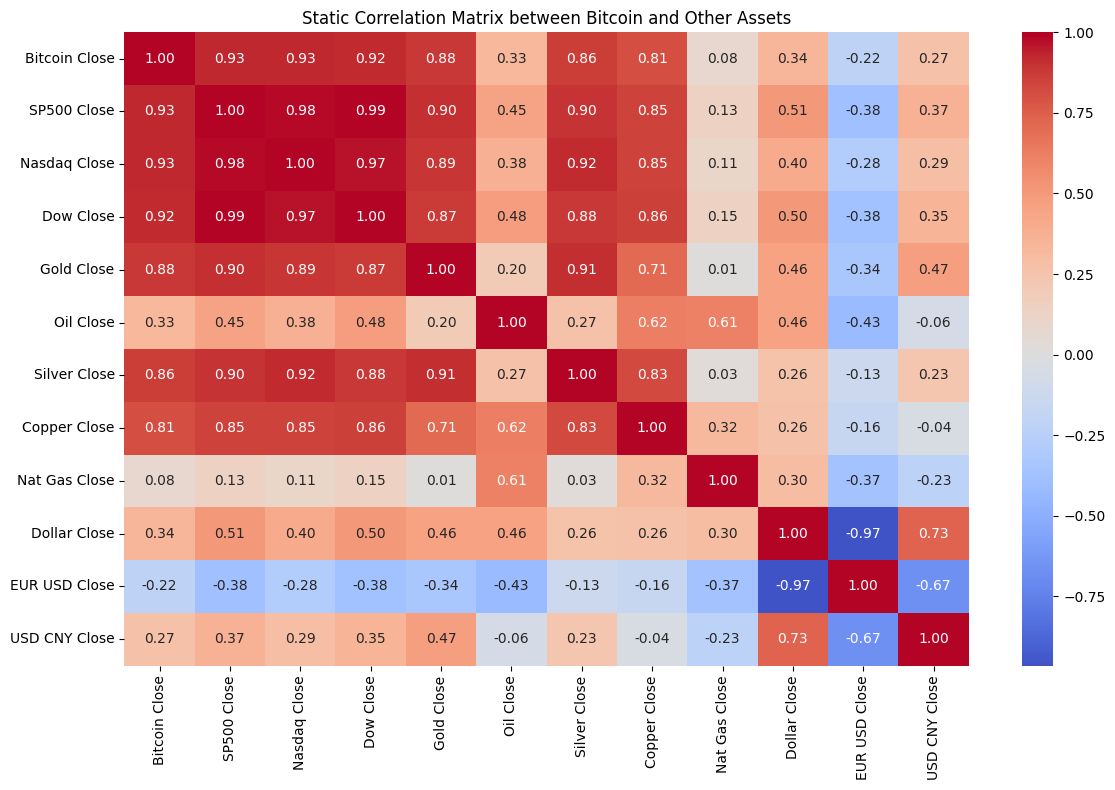

In [386]:
corr_matrix = df.drop(columns=['Date']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Static Correlation Matrix between Bitcoin and Other Assets")
plt.tight_layout()
plt.show()

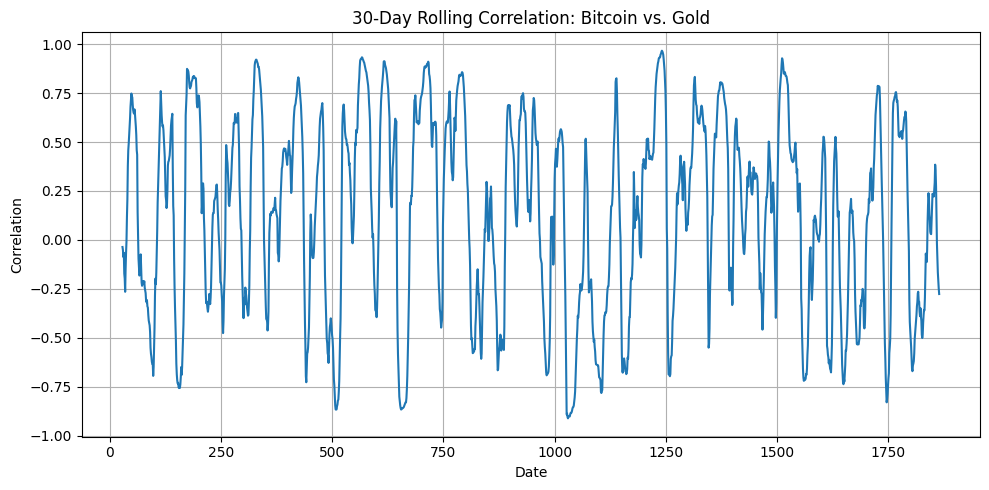

In [387]:
rolling_corr = df['Bitcoin Close'].rolling(window=30).corr(df['Gold Close'])

plt.figure(figsize=(10, 5))
rolling_corr.plot()
plt.title('30-Day Rolling Correlation: Bitcoin vs. Gold')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.grid(True)
plt.tight_layout()
plt.show()

In [391]:
split_date = pd.to_datetime("2024-01-01")

feature_cols = ["SP500 Close", "Nasdaq Close", "Dow Close", "Gold Close", "Oil Close", "Silver Close", 
                "Copper Close", "Nat Gas Close", "Dollar Close", "EUR USD Close", "USD CNY Close"]
target_col = "Bitcoin Close"

# Mask to split train and test sets
mask_train = df["Date"] < split_date
mask_test = df["Date"] >= split_date

# Split features and targets
X_train = df.loc[mask_train, feature_cols]
X_test = df.loc[mask_test, feature_cols]
y_train = df.loc[mask_train, target_col]
y_test = df.loc[mask_test, target_col]

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 500}
Tuned R² Score: -3.1794857083330443


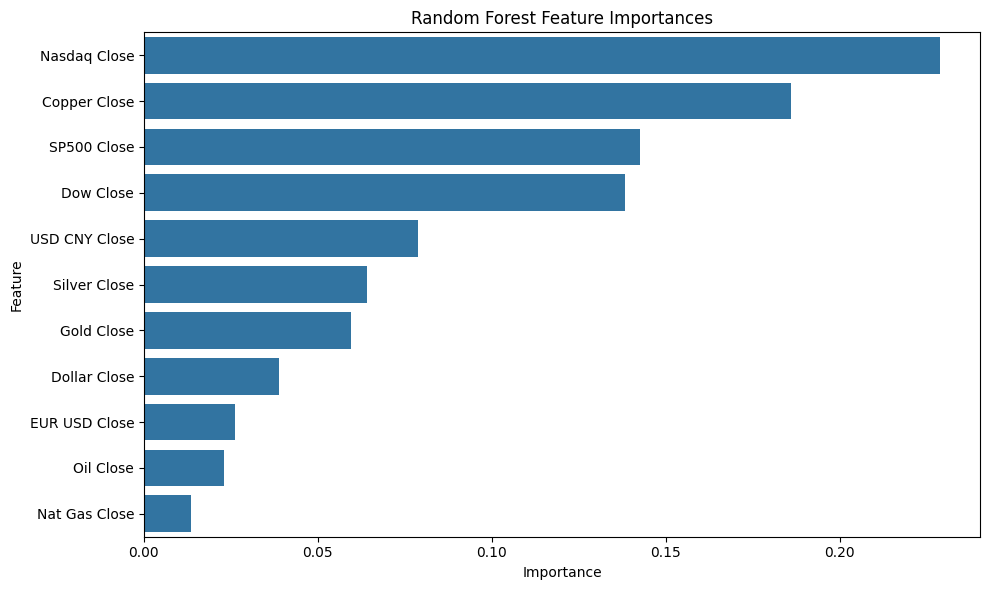

In [392]:
param_grid = {
    'n_estimators': [100, 300, 500],  # number of decision trees
    'max_depth': [5, 10, 20, None],   # maximum depth of each decision tree
    'min_samples_split': [2, 5],      # minimum samples required to split an internal node
    'max_features': ['sqrt', 'log2']  # best split criteria
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)
print("Best Parameters:", grid.best_params_)
print("Tuned R² Score:", r2_score(y_test, y_pred))

importances = best_rf.feature_importances_
features = X.columns
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()


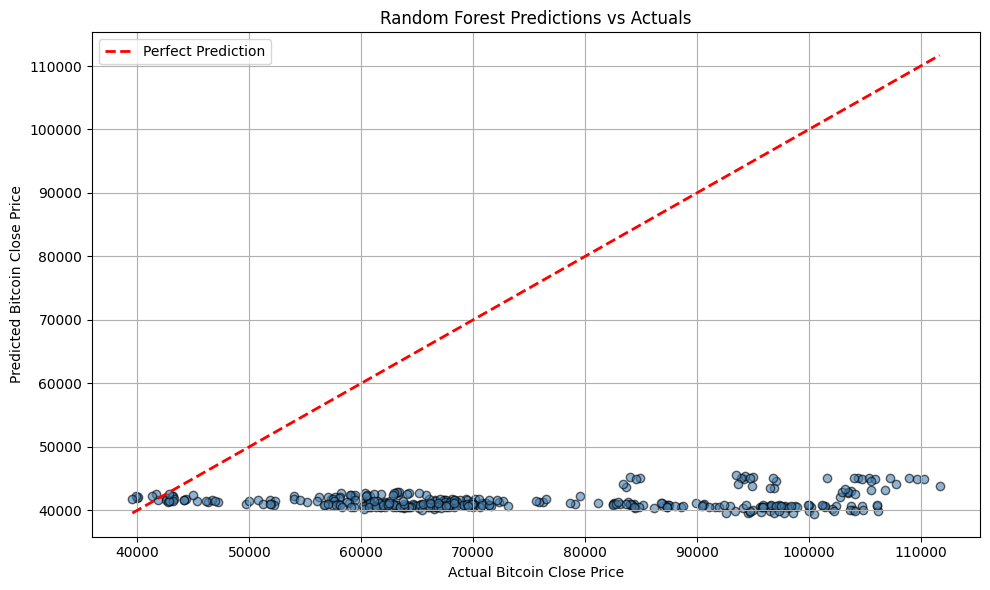

In [393]:
y_test_flat = y_test.values.ravel()

# Plot predicted vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_flat, y_pred, alpha=0.6, color='steelblue', edgecolors='k')
plt.plot([y_test_flat.min(), y_test_flat.max()],
         [y_test_flat.min(), y_test_flat.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Bitcoin Close Price")
plt.ylabel("Predicted Bitcoin Close Price")
plt.title("Random Forest Predictions vs Actuals")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()